# Kısıtsız Minimizasyon Problemi

## 1. Problemin Tanımı
Bu çalışmanın amacı, aşağıda verilen iki değişkenli, konveks ve karesel (quadratic) fonksiyonun global minimum noktasını tespit etmektir:

$$g(x, y) = x^2 + xy + 2y^2 + 5x + 3y$$

Çalışma, problemin çözümü için hibrit bir yaklaşım benimsemektedir:

* **Analitik (Sembolik) Çözüm:** Python'un SymPy kütüphanesi kullanılarak matematiksel türevlerin ve denklem sistemlerinin otomatize edilmesi.
* **Nümerik Çözüm:** Gradient Descent, Steepest Descent ve Newton Yöntemi algoritmalarının sıfırdan (from scratch) kodlanarak performanslarının kıyaslanması.

## 2. Analitik Çözüm ve Kod Mimarisi
Bu bölümde, önce problemin teorik matematiksel çözümü adım adım sunulmuş, ardından Python kodunun bu süreci nasıl otomatize ettiği açıklanmıştır.

### A. Matematiksel İspat (Teorik Arkaplan)
Bir fonksiyonun yerel ekstremum noktaları, gradyan vektörünün (kısmi türevlerin) sıfır olduğu noktalardır ($\nabla g = 0$).

**Adım 1: Kısmi Türevlerin Hesaplanması**
$$\frac{\partial g}{\partial x} = 2x + y + 5$$
$$\frac{\partial g}{\partial y} = x + 4y + 3$$

**Adım 2: Denklem Sisteminin Çözümü**
Minimum nokta için türevler sıfıra eşitlenir ve lineer denklem sistemi çözülür:
$$2x + y = -5$$
$$x + 4y = -3$$

İkinci denklem $-2$ ile çarpılıp taraf tarafa toplanırsa:
$$(2x + y) - 2(x + 4y) = -5 + 6 \implies -7y = 1 \implies \mathbf{y^* = -1/7}$$
$$x + 4(-1/7) = -3 \implies x = -17/7 \implies \mathbf{x^* = -17/7}$$

**Analitik Sonuç:** $(-2.4286, -0.1428)$

**Adım 3: Konvekslik Kontrolü (Hessian Matrisi)**
$$H = \begin{bmatrix} 2 & 1 \\ 1 & 4 \end{bmatrix}$$
Determinant ($7 > 0$) ve İz ($6 > 0$) pozitif olduğu için fonksiyon konvekstir ve bulunan nokta global minimumdur.

### B. Kod Mimarisi ve Otomasyon (Python Implementation)
Geliştirilen Python kodu, yukarıdaki matematiksel işlemleri "hard-coded" (elle yazılmış) olarak değil, dinamik ve sembolik olarak gerçekleştirmektedir. Kodun analitik çözüm bloğunda uyguladığı mimari şöyledir:

* **Sembolik Diferansiyel (sp.diff):**
Fonksiyonun türevleri elle hesaplanıp koda yazılmamıştır. Kod, `sp.diff(func, x)` komutuyla fonksiyon ne kadar karmaşık olursa olsun gradyan vektörünü ve Hessian matrisini dinamik olarak türetir.

* **Denklem Sistemi Çözücü (sp.solve):**
Kod, $\nabla g = 0$ sistemini bir matris problemi olarak ele alır ve kökleri (`solutions`) sembolik kütüphane aracılığıyla çözer. Bu, insan hatasını (algebraic error) ortadan kaldırır.

* **Özdeğer Analizi ile Doğrulama (eigenvals):**
Bulunan aday noktaların minimum olup olmadığı, kod tarafından Hessian matrisinin Özdeğerleri (Eigenvalues) hesaplanarak kontrol edilir. Kod, sadece tüm özdeğerleri pozitif olan noktaları "Onaylı Minimum" olarak işaretler.

* **Lambdify Dönüşümü:**
Sembolik olarak türetilen denklemler, `sp.lambdify` kullanılarak yüksek performanslı NumPy fonksiyonlarına dönüştürülür ve nümerik algoritmaların kullanımına hazır hale getirilir.

## 3. Algoritmik Yaklaşım (Python Uygulaması)
Analitik olarak doğruladığımız bu sonuca, başlangıç noktası $(0,0)$ kabul edilerek üç farklı iteratif yöntemle ulaşılmaya çalışılmıştır:

* **Gradient Descent (GD):** Sabit öğrenme oranı (Learning Rate = 0.1) ile gradyanın tersi yönünde ilerler.
* **Steepest Descent (SD):** Yönü gradyandan alır ancak adım büyüklüğünü (Step Size) her iterasyonda `minimize_scalar` (Line Search) yöntemiyle optimize eder. Adımları birbirine ortogonaldir.
* **Newton's Method:** İkinci türev bilgisini (Hessian Matrisi) kullanarak fonksiyonun eğriliğini hesaba katar. Fonksiyon karesel olduğu için teorik olarak tek adımda sonuca ulaşması beklenir.

Aşağıdaki Python kodu, bu süreci otomatize etmekte ve algoritmaların izlediği yolları kontur grafiği üzerinde görselleştirmektedir.

ANALİTİK ÇÖZÜM
 -> Aday Nokta Bulundu: (-2.4286, -0.1429)
ONAY: Bu nokta bir Yerel Minimum. Değer: -6.2857
>>> Analitik Global Min: x=-2.4286, y=-0.1429
>>> Fonksiyon Değeri : -6.2857
Algoritmalar Çalıştırılıyor...
1. Gradient Descent (LR=0.1): 89 iterasyon. Sonuç: [-2.42857092 -0.14285735]
2. Steepest Descent (Opt. LR): 21 iterasyon. Sonuç: [-2.42857107 -0.14285713]
3. Newton's Method:           2 iterasyon. Sonuç: [-2.42857143 -0.14285714]


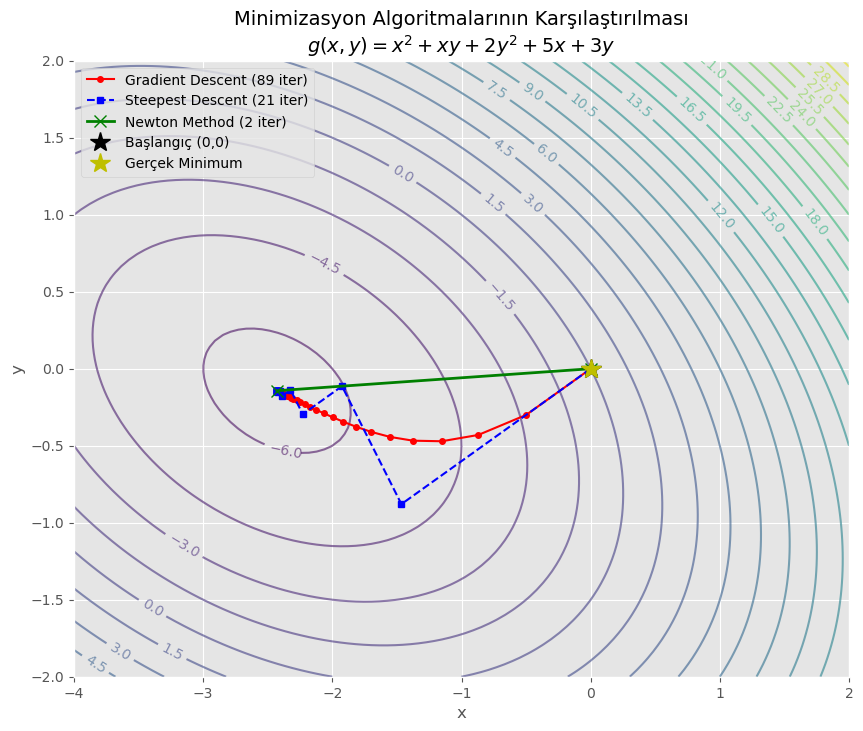

In [2]:
import numpy as np  # Sayısal hesaplamalar, matris ve vektör işlemleri için ana kütüphaneyi çağırır.
import sympy as sp  # Sembolik matematik (türev, denklem çözümü) işlemleri için kütüphaneyi çağırır.
import matplotlib.pyplot as plt  # Grafik çizimi ve veri görselleştirme için pyplot modülünü çağırır.
from scipy.optimize import minimize_scalar  # Tek değişkenli minimizasyon (Line Search) için gerekli fonksiyonu çağırır.

# 1. AYARLAR
# Grafiklerin boyutunu (genişlik 12, yükseklik 8 inç) ayarlar, böylece detaylar net görünür.
plt.rcParams['figure.figsize'] = (12, 8)
# Grafiklerin stilini 'ggplot' yapar, bu daha estetik ve akademik bir arka plan sağlar.
plt.style.use('ggplot')

def optimization_bonus_1():  # Tüm optimizasyon sürecini kapsayan ana fonksiyonu tanımlar.

    # 2. ANALİTİK ÇÖZÜM
    
    print("ANALİTİK ÇÖZÜM")  # Konsola işlemin başladığını belirten başlık yazar.
    
    # Sembolik değişken tanımlama: x ve y'yi matematiksel sembol olarak tanıtır.
    x, y = sp.symbols('x y')
    # Amaç fonksiyonunu (minimize edilecek denklemi) sembolik olarak tanımlar.
    func = x**2 + x*y + 2*y**2 + 5*x + 3*y
    
    # Fonksiyonun x'e göre kısmi türevini alır.
    grad_x = sp.diff(func, x)
    # Fonksiyonun y'ye göre kısmi türevini alır.
    grad_y = sp.diff(func, y)
    # İki türevi birleştirerek Gradyan Vektörünü (sistemi) oluşturur.
    gradient = [grad_x, grad_y] 
    
    # Hessian Matrisini (İkinci türevler matrisi) oluşturur.
    # [f_xx, f_xy]
    # [f_yx, f_yy] yapısındadır.
    hessian_matrix = sp.Matrix([[sp.diff(func, x, x), sp.diff(func, x, y)],
                                [sp.diff(func, y, x), sp.diff(func, y, y)]])
    
    # Sembolik fonksiyonu, sayısal (Numpy) fonksiyonuna çevirir (Hız için).
    f_func = sp.lambdify((x, y), func, 'numpy')
    # Sembolik gradyanı, sayısal fonksiyona çevirir.
    grad_num_func = sp.lambdify((x, y), gradient, 'numpy') 
    # Sembolik hessian'ı, sayısal fonksiyona çevirir.
    hess_num_func = sp.lambdify((x, y), hessian_matrix, 'numpy')

    # Analitik çözüm değişkenlerini başlatır (Global min ve aday listesi).
    global_min = None 
    local_mins = []
    candidates = []
    
    # Adım A: Gradyan denklemlerini (türevleri) sıfıra eşitleyip çözer.
    solutions = sp.solve(gradient, (x, y), dict=True)
    
    # Bulunan her bir çözüm (kök) için döngü başlatır.
    for sol in solutions:
        # Hata yakalama bloğu: Karmaşık sayı (complex) gelirse kodun patlamaması için.
        try:
            # Çözümdeki x değerini ondalıklı sayıya (float) çevirir.
            x_val = float(sol[x])
            # Çözümdeki y değerini ondalıklı sayıya (float) çevirir.
            y_val = float(sol[y])
        except TypeError:
            # Eğer sayı reel değilse (complex ise) bu adayı atlar.
            continue 
    
        print(f" -> Aday Nokta Bulundu: ({x_val:.4f}, {y_val:.4f})") # Bulunan adayı ekrana yazar.
        
        # Adım B: Hessian Kontrolü (Minimum testi).
        # Hessian matrisine o noktadaki x ve y değerlerini koyar.
        H_at_point = hessian_matrix.subs({x: x_val, y: y_val})
        
        # O noktadaki matrisin özdeğerlerini (eigenvalues) hesaplar.
        eigenvals = list(H_at_point.eigenvals().keys())
        
        # Tüm özdeğerlerin 0'dan büyük olup olmadığını kontrol eder (Konvekslik şartı).
        is_minimum = all(float(ev) > 0 for ev in eigenvals)
        
        # Eğer minimum şartını sağlıyorsa listeye ekler.
        if is_minimum:
            # O noktadaki fonksiyon değerini hesaplar.
            f_val = f_func(x_val, y_val)
            # Aday listesine ((x,y), değer) formatında ekler.
            candidates.append(((x_val, y_val), f_val))
            print(f"ONAY: Bu nokta bir Yerel Minimum. Değer: {f_val:.4f}")
        else:
            print(f"RET: Bu nokta minimum değil.") 
    
    # Grafik çiziminde kullanılacak doğru minimum değişkeni.
    # Güvenlik önlemi: Eğer hiçbir minimum noktası bulamasaydı grafik çizimi için tasarlanan kodun patlamaması adına (0,0) verilirdi.
    true_min_coords = (0, 0)

    # 4. Minimumları Sırala ve Seç
    if candidates: # Eğer aday varsa
        candidates.sort(key=lambda p: p[1]) # Fonksiyon değerine göre küçükten büyüğe sıralar.
        global_min = candidates[0] # En küçüğü global minimum seçer.
        local_mins = candidates[1:] # Varsa diğerlerini yerel min yapar.
        
        # Grafik için koordinatları saklıyoruz.
        print(f">>> Analitik Global Min: x={global_min[0][0]:.4f}, y={global_min[0][1]:.4f}") 
        print(f">>> Fonksiyon Değeri : {global_min[1]:.4f}")
    else:
        print("Minimum nokta bulunamadı.") # Hiçbir nokta bulunamazsa uyarı verir.

    # 3. ALGORİTMALARIN KURULUMU
    
    start_point = np.array([0.0, 0.0]) # Algoritmaların başlayacağı ilk nokta (x=0, y=0).
    tol = 1e-6 # Durma kriteri: Gradyan bu değerden küçükse "buldum" sayar.
    max_iter = 100 # Sonsuz döngüye girmemek için maksimum adım sayısı.

    # Fonksiyon tanımları içinde kullanmak için global lambdify fonksiyonlarını sarmalar
    # (Bu işlem, iç fonksiyonların dıştaki lambdify nesnelerine erişimini netleştirir).
    def get_grad(c): return np.array(grad_num_func(c[0], c[1])).flatten().astype(float)
    def get_hess(c): return np.array(hess_num_func(c[0], c[1])).astype(float)
    def get_val(c): return float(f_func(c[0], c[1]))

    # A) GRADIENT DESCENT
    def gradient_descent(start_pos, learning_rate=0.1): 
        path = [start_pos] # Gidilen yolu tutan liste, başlangıç noktası eklendi.
        curr = start_pos # Geçerli konumu başlangıca eşitler.
        for i in range(max_iter): # Maksimum iterasyon kadar döner.
            g_val = get_grad(curr) # O noktadaki gradyanı hesaplar.
            
            if np.linalg.norm(g_val) < tol: # Gradyan vektörünün büyüklüğü toleranstan küçükse döngüyü kırar.
                break
            
            next_pos = curr - learning_rate * g_val # Formül: Yeni = Eski - (Hız * Gradyan)
            path.append(next_pos) # Yeni noktayı yola ekler.
            curr = next_pos # Geçerli konumu günceller.
        return np.array(path), i+1 # Yolu ve kaç adım sürdüğünü döndürür.

    # B) STEEPEST DESCENT (En Dik İniş - Line Search)
    # Yönü yine gradyandan alır (bu açıdan GD ile kardeştir), ancak adımı atarken matematiksel bir hesap yapar.
    def steepest_descent(start_pos): # Fonksiyon tanımı.
        path = [start_pos] # Yolu tutan liste.
        curr = start_pos # Geçerli konum.
        for i in range(max_iter): # Döngü başlangıcı.
            g_val = get_grad(curr) # Gradyan hesabı.
            
            if np.linalg.norm(g_val) < tol: # Durma kontrolü.
                break
            
            # Line Search Alt Fonksiyonu: O yönde ne kadar gitmeliyim?
            def func_to_minimize_step(alpha): # Alpha (adım boyu) değişkenine göre fonksiyon.
                candidate = curr - alpha * g_val # Aday noktayı hesaplar.
                return get_val(candidate) # O noktanın değerini döndürür.
            
            # Scipy minimize_scalar ile en iyi alpha'yı bulur.
            res = minimize_scalar(func_to_minimize_step) 
            best_alpha = res.x # En iyi adım büyüklüğünü alır.
            
            next_pos = curr - best_alpha * g_val # En iyi adımı kullanarak ilerler.
            path.append(next_pos) # Yola ekler.
            curr = next_pos # Konumu günceller.
        return np.array(path), i+1 # Sonuçları döndürür.

    # C) NEWTON'S METHOD (Hessian Kullanımı)
    def newton_method(start_pos): # Fonksiyon tanımı.
        path = [start_pos] # Yolu tutan liste.
        curr = start_pos # Geçerli konum.
        for i in range(max_iter): # Döngü.
            g_val = get_grad(curr) # Gradyan.
            H_val = get_hess(curr) # Hessian matrisi (Eğrilik).
            
            if np.linalg.norm(g_val) < tol: # Durma kontrolü.
                break
            
            # Newton Adımı: Sistem çözümü (H * step = g) -> step = H^-1 * g
            step = np.linalg.solve(H_val, g_val) # Matris denklemini çözer (Ters almaktan daha güvenlidir).
            
            next_pos = curr - step # Yeni konumu hesaplar.
            path.append(next_pos) # Yola ekler.
            curr = next_pos # Günceller.
        return np.array(path), i+1 # Sonuçları döndürür.

    # ÇALIŞTIRMA VE KIYASLAMA
    
    print("Algoritmalar Çalıştırılıyor...") # Bilgi mesajı.
    path_gd, iter_gd = gradient_descent(start_point, learning_rate=0.1) 
    path_sd, iter_sd = steepest_descent(start_point) 
    path_nm, iter_nm = newton_method(start_point) 
    
    # Sonuçları ekrana yazdırır.
    print(f"1. Gradient Descent (LR=0.1): {iter_gd} iterasyon. Sonuç: {path_gd[-1]}")
    print(f"2. Steepest Descent (Opt. LR): {iter_sd} iterasyon. Sonuç: {path_sd[-1]}")
    print(f"3. Newton's Method:           {iter_nm} iterasyon. Sonuç: {path_nm[-1]}")
    
    #GÖRSELLEŞTİRME
    
    # Kontur grafiği için zemin (grid) oluşturur.
    x_range = np.linspace(-4, 2, 100) # x ekseni aralığı.
    y_range = np.linspace(-2, 2, 100) # y ekseni aralığı.
    X, Y = np.meshgrid(x_range, y_range) # Izgara (mesh) oluşturur.
    Z = f_func(X, Y) # Her nokta için yükseklik (Z) değerini hesaplar.
    
    plt.figure(figsize=(10, 8)) # Yeni bir resim çerçevesi açar.
    # Kontur çizgilerini çizer (levels=30 çizgi sayısıdır).
    cp = plt.contour(X, Y, Z, levels=30, cmap='viridis', alpha=0.6) 
    plt.clabel(cp, inline=True, fontsize=10) # Çizgilerin üzerine değerleri yazar.
    
    # Hesaplanan yolları grafik üzerine çizer.
    plt.plot(path_gd[:,0], path_gd[:,1], 'o-', label=f'Gradient Descent ({iter_gd} iter)', color='red', markersize=4) # GD Yolu (Kırmızı)
    plt.plot(path_sd[:,0], path_sd[:,1], 's--', label=f'Steepest Descent ({iter_sd} iter)', color='blue', markersize=4) # SD Yolu (Mavi Kesikli)
    plt.plot(path_nm[:,0], path_nm[:,1], 'x-', label=f'Newton Method ({iter_nm} iter)', color='green', markersize=8, linewidth=2) # Newton Yolu (Yeşil)
    
    # Başlangıç noktasını işaretler (Siyah Yıldız).
    plt.plot(start_point[0], start_point[1], 'k*', markersize=15, label='Başlangıç (0,0)')
    
    # Gerçek Minimum noktasını işaretler (Sarı Yıldız).
    plt.plot(true_min_coords[0], true_min_coords[1], 'y*', markersize=15, label='Gerçek Minimum')
    
    plt.title('Minimizasyon Algoritmalarının Karşılaştırılması\n$g(x, y) = x^2 + xy + 2y^2 + 5x + 3y$', fontsize=14) # Başlık.
    plt.xlabel('x') 
    plt.ylabel('y') 
    plt.legend() # Lejantı (hangi renk ne demek) gösterir.
    plt.grid(True) # Arka plana kareli ızgara koyar.
    plt.show() 

if __name__ == "__main__":
    optimization_bonus_1() 